In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.seterr(divide='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [5]:
states = ['E', '5', 'I'] #наши состояния
abs_dict = {'A' : 0, 'C' : 1, 'G' : 2, 'T' : 3} #наши наблюдения

pi = np.array([1.0, 0.0, 0.0]) #начальные вероятности ($\pi_i$)
exit_prob = np.array([0.0, 0.0, 0.1]) #выход из I с вероятностью 0.1

#Матрица переходов A:
A = np.array([
    [0.9, 0.1, 0.0],
    [0.0, 0.0, 1.0],
    [0.0, 0.0, 0.9]
])

#Матрица эмиссий E:
E = np.array([
    [0.25, 0.25, 0.25, 0.25],  
    [0.05, 0.00, 0.95, 0.00],  
    [0.40, 0.10, 0.10, 0.40]   
])

#Посл-ть из исходной статьи:
seq ='CTTCATGTGAAAGCAGACGTAAGTCA'
print(f'Последовательность: {seq}, длины {len(seq)} п.н.')

Последовательность: CTTCATGTGAAAGCAGACGTAAGTCA, длины 26 п.н.


In [7]:
#2.1 Алгоритм Витерби:

def viterbi(seq, pi, A, E, exit_prob):
    #Закодируем посл-ть:
    abs_dict = {'A' : 0, 'C' : 1, 'G' : 2, 'T' : 3}
    abs_seq = [abs_dict[i] for i in seq]
    T = len(abs_seq)
    K = len(pi)

    #Переведем все в логарифмический масштаб:
    log_pi = np.log(pi + 1e-300)
    log_A = np.log(A + 1e-300)
    log_E = np.log(E + 1e-300)
    log_exit = np.log(exit_prob)
    
    #Инициализируем:
    delta = np.zeros((K, T))
    psi = np.zeros((K, T), dtype=int)

    #t=0:
    for s in range(K):
        delta[s, 0] = log_pi[s] + log_E[s, abs_seq[0]]

    #Рекурсия:
    for t in range(1, T):
        for s in range(K):
            max_val = -np.inf
            max_prev = -1
            for prev in range(K):
                val = delta[prev, t-1] + log_A[prev, s]
                if val > max_val:
                    max_val = val
                    max_prev = prev
            if max_val > -np.inf:
                delta[s, t] = max_val + log_E[s, abs_seq[t]]
                psi[s, t] = max_prev

    #Завершение:
    best_last = -1
    best_val = -np.inf
    for s in range(K):
        val = delta[s, -1] + log_exit[s]
        if val > best_val:
            best_val = val
            best_last = s
    
    logprob = best_val

    #Backtracking:
    path = [best_last]
    for t in range(T-1, 0, -1):
        path.insert(0, psi[path[0], t])

    return path, log_prob, delta, psi

path, log_prob, delta, psi = viterbi(seq, pi, A, E, exit_prob)
path_states = [states[s] for s in path]
path_str = ''.join(path_states)

print(f'Посл-ть скрытых сост-й: {path_str}')
print(f'Вероятность этой посл-ти: {np.exp(log_prob):.2e}')

Посл-ть скрытых сост-й: EEEEEEEEEEEEEEEEEE5IIIIIII
Вероятность этой посл-ти: 1.59e-17


Рассчитанный наиболее вероятный путь скрытых состояний для данной цепи совпадает с данными из статьи. Однако, стоит упомянуть, что сначала не учел выход из состояния I, это давало чисто последовательность из экзонов.

In [9]:
#2.2 Алгоритм Forward:

def forward(seq, pi, A, E, exit_prob):
    #Закодируем посл-ть:
    abs_dict = {'A' : 0, 'C' : 1, 'G' : 2, 'T' : 3}
    abs_seq = [abs_dict[i] for i in seq]
    T = len(abs_seq)
    K = len(pi)

    #Переведем все в логарифмический масштаб:
    log_pi = np.log(pi + 1e-300)
    log_A = np.log(A + 1e-300)
    log_E = np.log(E + 1e-300)
    log_exit = np.log(exit_prob)

    #Инициализуем:
    alpha = np.full((K, T), -np.inf)
    for s in range(K):
        alpha[s, 0] = log_pi[s] + log_E[s, abs_seq[0]]

    #Рекурсия:
    for t in range(1, T):
        for s in range(K):
            log_sum = -np.inf
            for prev in range(K):
                val = alpha[prev, t-1] + log_A[prev, s]
                log_sum = np.logaddexp(log_sum, val)
            alpha[s, t] = log_sum + log_E[s, abs_seq[t]]

    #Полная вероятность:
    total_logprob = -np.inf
    for s in range(K):
        total_logprob = np.logaddexp(total_logprob, alpha[s, -1] + log_exit[s])

    return alpha, total_logprob

alpha, log_prob = forward(seq, pi, A, E, exit_prob)

print(f'Логарифм полной вероятности: {log_prob:.5f}')
print(f'Сама вероятность: P (O | $\lambda$) = {np.exp(log_prob):.2e}')

Логарифм полной вероятности: -40.44743
Сама вероятность: P (O | $\lambda$) = 2.72e-18


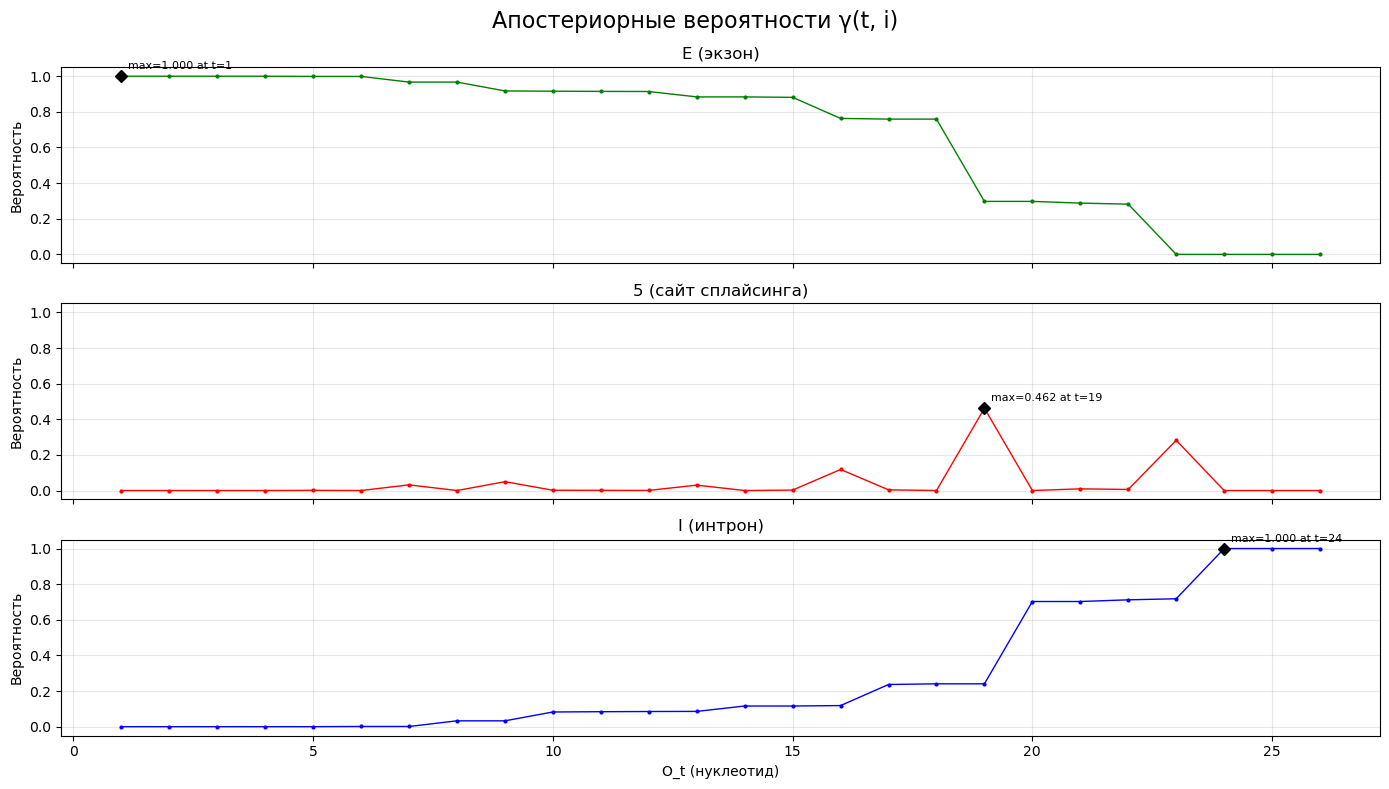

In [13]:
#2.3 Апостероидное декодирование:

#2.3.1 Алгоритм Backward:

def backward(seq, A, E, exit_probs):
    #Закодируем посл-ть:
    abs_dict = {'A' : 0, 'C' : 1, 'G' : 2, 'T' : 3}
    abs_seq = [abs_dict[i] for i in seq]

    #Переведем все в логарифмический масштаб:
    log_pi = np.log(pi + 1e-300)
    log_A = np.log(A + 1e-300)
    log_E = np.log(E + 1e-300)
    log_exit = np.log(exit_prob)

    T = len(abs_seq)
    K = log_A.shape[0]

    #Инициализируем:
    beta = np.full((K, T), -np.inf)
    for s in range(K):
        beta[s, -1] = log_exit[s]

    #Рекурсия:
    for t in range(T-2, -1, -1):
        for s in range(K):
            log_sum = -np.inf
            for nxt in range(K):
                val = log_A[s, nxt] + log_E[nxt, abs_seq[t+1]] + beta[nxt, t+1]
                log_sum = np.logaddexp(log_sum, val)
            beta[s, t] = log_sum
    
    return beta

beta = backward(seq, A, E, exit_prob)

#2.3.2 Само апостероидное декодирование:

def aposteroid_decoding(seq, states, alpha, beta):
    T = len(seq)
    K = len(states)

    gamma = np.zeros((K, T))
    for t in range(T):
        log_sum = -np.inf
        for s in range(K):
            log_sum = np.logaddexp(log_sum, alpha[s, t] + beta[s, t])
        for s in range(K):
            gamma[s, t] = np.exp(alpha[s, t] + beta[s, t] - log_sum)

    return gamma

gamma = aposteroid_decoding(seq, states, alpha, beta)

#Графики:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

T = len(seq)

state_names = ['E (экзон)', '5 (сайт сплайсинга)', 'I (интрон)']
colors = ['green', 'red', 'blue']

for i, (name, color) in enumerate(zip(state_names, colors)):
    axes[i].plot(range(1, T+1), gamma[i, :], marker='o', color=color, linewidth=1, markersize=2)
    
    # Находим максимум
    max_pos = np.argmax(gamma[i, :])
    max_val = gamma[i, max_pos]
    axes[i].plot(max_pos+1, max_val, 'D', color='black', markersize=6)
    axes[i].annotate(f'max={max_val:.3f} at t={max_pos+1}', 
                     xy=(max_pos+1, max_val), xytext=(5, 5),
                     textcoords='offset points', fontsize=8)
    axes[i].set_ylabel('Вероятность')
    axes[i].set_title(name)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(-0.05, 1.05)

axes[-1].set_xlabel('O_t (нуклеотид)')
plt.suptitle('Апостериорные вероятности γ(t, i)', fontsize=16)
plt.tight_layout()
plt.show()